In [1]:
# Imports
import sys
sys.path.insert(1, '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/')
import importlib
import numpy as np
import awkward as ak
# import pandas as pd
# from particle import Particle
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
#from mpl_toolkits.mplot3d import Axes3D
from python.analysis import BeamParticleSelection, Master, SelectionTools, vector
from python.analysis import SelectionEvaluation as seval
from python.analysis import Tags, Plots
from python.pdhd_MC import beam_selection
importlib.reload(Master)
importlib.reload(BeamParticleSelection)
importlib.reload(SelectionTools)
importlib.reload(Tags)
importlib.reload(beam_selection)

<module 'python.pdhd_MC.beam_selection' from '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/python/pdhd_MC/beam_selection.py'>

In [2]:
filename = "/storage/2/gj23442/pdhd_prod_mc_beam__gen_g4_IonScintPDExt_PDInt_1GeV_v10_10_04d01_nosce.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [3]:
## Beam Instrumentation Selection

true_beam_mask = beam_selection.BeamTriggerSelection(events, return_property=True)
mask = true_beam_mask[0]
bi_evts = events.Filter([mask], [mask], returnCopy=True)

In [4]:
mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

In [5]:
mask = bv_evts.recoParticles.beam_pandora_tag == 13
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

0


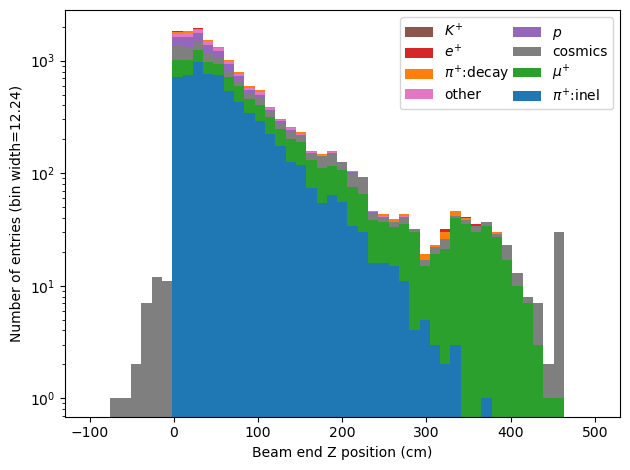

In [6]:
end_pos = track_evts.recoParticles.beam_endPos_SCE
tags = Tags.GenerateBeamCandidateTags(track_evts)
print(ak.sum(end_pos.z == -999))
Plots.PlotTagged(end_pos.z, tags, bins=np.linspace(-100, 500, 50), y_scale='log', x_label="Beam end Z position (cm)")

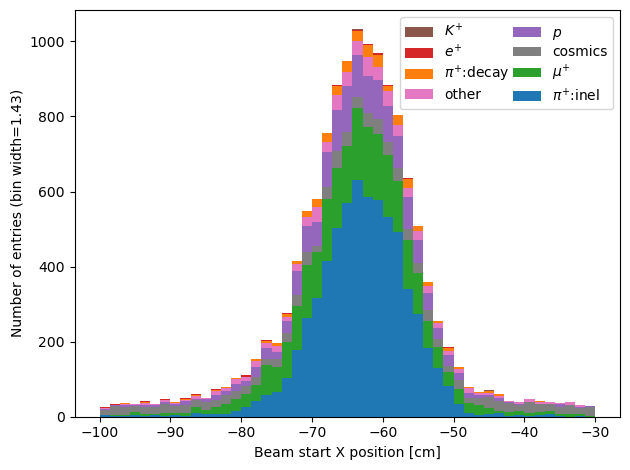

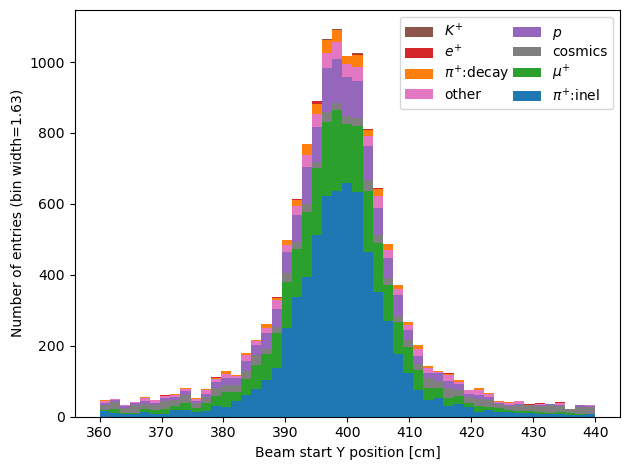

In [7]:
tags = Tags.GenerateBeamCandidateTags(track_evts)
reco_startpos = track_evts.recoParticles.beam_startPos

bins_x = np.linspace(-100, -30, 50)
Plots.PlotTagged(reco_startpos.x, tags, bins=bins_x, x_label="Beam start X position [cm]")
plt.show()

bins_y = np.linspace(360, 440, 50)
Plots.PlotTagged(reco_startpos.y, tags, bins=bins_y, x_label="Beam start Y position [cm]")
plt.show()

2026-06-04 10:04:02.158477: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


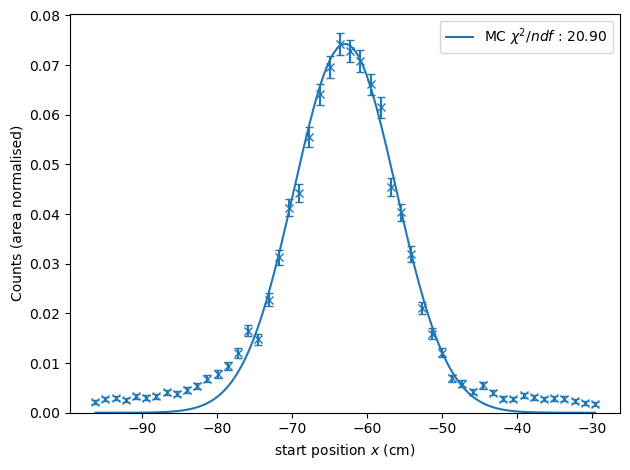

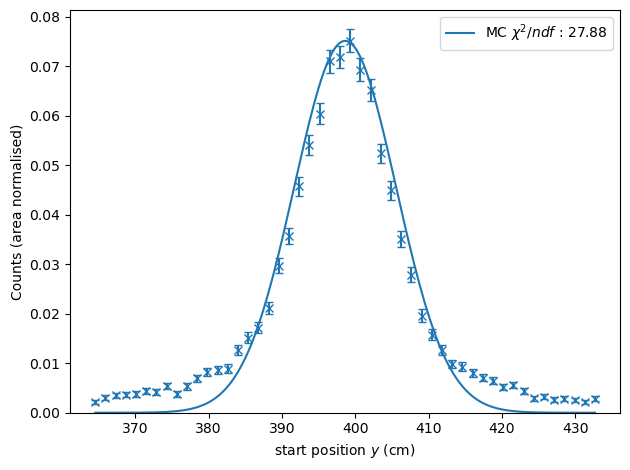

In [6]:
from python.analysis import Fitting, cross_section
import apps.cex_beam_quality_fits as beam_qual

mu, mu_err, sigma, sigma_err = {}, {}, {}, {}
reco_startpos = track_evts.recoParticles.beam_startPos

def range_from_percentiles(data, lower=10, upper=90):
    return sorted([np.nanpercentile(data, lower), np.nanpercentile(data, upper)])  
 
range = {"x": range_from_percentiles(reco_startpos.x, lower=10, upper=90),
         "y": range_from_percentiles(reco_startpos.y, lower=20, upper=90)}

for i in ["x", "y"]:
    data = reco_startpos[i]

    # fit only to data within the 10th and 90th percentile of data to exclude large tails in the distriubtion.
    y, bins_edges = np.histogram(np.array(data[~np.isnan(data)]), bins = 10, range = range[i]) 

    yerr = np.sqrt(y) # Poisson error

    popt, perr = Fitting.Fit(cross_section.bin_centers(bins_edges), y, yerr, Fitting.gaussian)

    mu[i] = popt[1]
    sigma[i] = abs(popt[2])
    mu_err[i] = abs(perr[1])
    sigma_err[i] = abs(perr[2])



def plot_range(mu, sigma):
    return [mu - 5*sigma, mu + 5*sigma]

plot_ranges = {i: plot_range(mu[i], sigma[i]) for i in ["x", "y"]}

for i in ["x", "y"]:
    beam_qual.plot(reco_startpos[i], f"start position ${i}$ (cm)", mu[i], sigma[i], "C0", "MC", range = [min(plot_ranges[i]), max(plot_ranges[i])])
    plt.show()

[<Array [True, True, True, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... True, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, True] type='13966 * bool'>] ['$\\pi^{+}$:inel', '$\\pi^{+}$:decay', '$\\mu^{+}$', '$e^{+}$', '$p$', '$K^{+}$', 'other', 'cosmics']


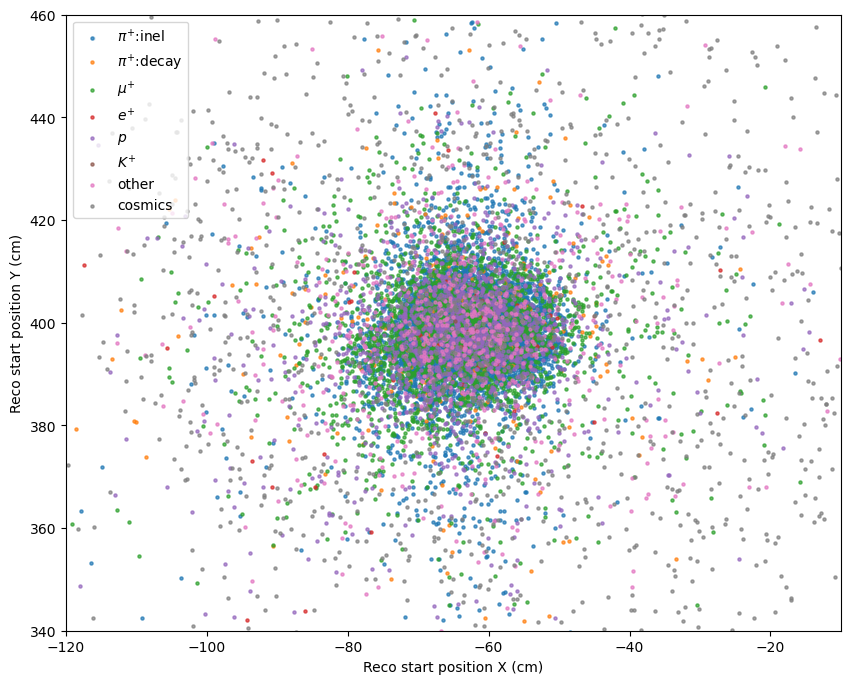

In [9]:
rng = np.array([0.5, 1, 1.5, 2, 3, 4, 5, 6, 7])
tags = Tags.GenerateBeamCandidateTags(track_evts)
print(tags.mask.values,tags.name.values)

reco_startpos = track_evts.recoParticles.beam_startPos

reco_startpos_x = np.array(reco_startpos.x)
reco_startpos_y = np.array(reco_startpos.y)

limit_x = [-120, -10]
limit_y = [340, 460]

plt.figure(figsize=(10, 8))

for mask, name in zip(tags.mask.values, tags.name.values):

    sel = np.array(mask).astype(bool)

    plt.scatter(
        reco_startpos_x[sel],
        reco_startpos_y[sel],
        s=5,
        alpha=0.7,
        label=name
    )

plt.xlim(limit_x)
plt.ylim(limit_y)

plt.xlabel("Reco start position X (cm)")
plt.ylabel("Reco start position Y (cm)")

plt.legend()
plt.show()

[<Array [True, True, True, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... True, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, False] type='13966 * bool'>, <Array [False, False, False, ... False, True] type='13966 * bool'>] ['$\\pi^{+}$:inel', '$\\pi^{+}$:decay', '$\\mu^{+}$', '$e^{+}$', '$p$', '$K^{+}$', 'other', 'cosmics']


/tmp/ipykernel_4093884/2236154580.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


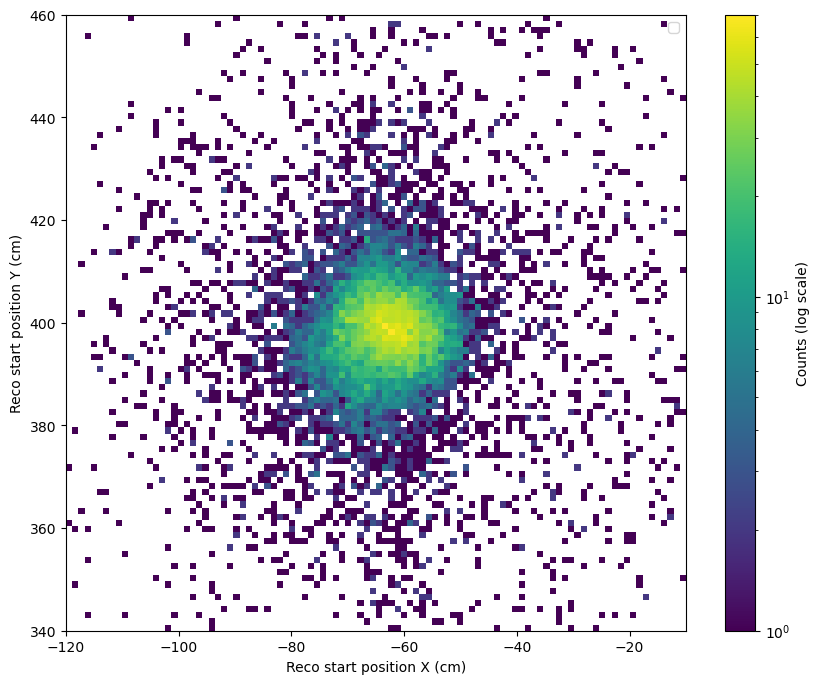

In [10]:
rng = np.array([0.5, 1, 1.5, 2, 3, 4, 5, 6, 7])
tags = Tags.GenerateBeamCandidateTags(track_evts)
print(tags.mask.values,tags.name.values)

reco_startpos = track_evts.recoParticles.beam_startPos

reco_startpos_x = np.array(reco_startpos.x)
reco_startpos_y = np.array(reco_startpos.y)

limit_x = [-120, -10]
limit_y = [340, 460]

plt.figure(figsize=(10, 8))

plt.hist2d(
    reco_startpos_x,
    reco_startpos_y,
    range=[limit_x, limit_y],
    bins=100,
    norm=mcolors.LogNorm()
)

plt.xlim(limit_x)
plt.ylim(limit_y)

# theta = np.linspace(0, 2*np.pi, 100)
# for j, m in enumerate(rng):
#     x = mu["x"] + m * sigma["x"] * np.cos(theta)
#     y = mu["y"] + m * sigma["y"] * np.sin(theta)
#     plt.plot(x, y, linestyle="--", label=f"{m}σ", linewidth=3)

plt.xlabel("Reco start position X (cm)")
plt.ylabel("Reco start position Y (cm)")

plt.legend()
plt.colorbar(label="Counts (log scale)")
plt.show()

In [7]:
reco_startpos = track_evts.recoParticles.beam_startPos

beam_dx = (reco_startpos.x - mu["x"])/ sigma["x"] 
beam_dy = (reco_startpos.y - mu["y"])/ sigma["y"]
beam_dxy = (beam_dx**2 + beam_dy**2)**0.5

In [8]:
tags = Tags.GenerateBeamCandidateTags(track_evts)

particle_tags = tags.name.values
masks = {name: tags.get(name).mask for name in particle_tags}

<Figure size 800x600 with 0 Axes>

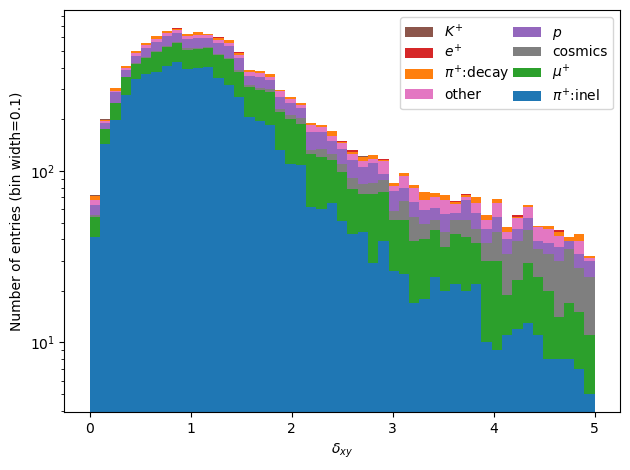

In [ ]:
from python.analysis import Plots
bins = np.linspace(0, 5, 50)
plt.figure(figsize=(8, 6))
Plots.PlotTagged(beam_dxy, tags, bins=bins, y_scale='log', x_label=r'$\delta_{xy}$')


In [14]:
ini_evts = beam_selection.signal_mask(track_evts)

def purity_efficiency(evts, filter_func):
    purity = ak.sum(filter_func(evts)) / len(filter_func(evts))
    efficiency = ak.sum(filter_func(evts)) / ak.sum(ini_evts)
    return purity, efficiency

In [15]:
purity, eff = [], []
for cut in rng:
    mask = beam_dxy < cut
    track_selected_evts = track_evts.Filter([mask], [mask], returnCopy=True)
    p, e = purity_efficiency(track_selected_evts, beam_selection.signal_mask)
    purity.append(p)
    eff.append(e)

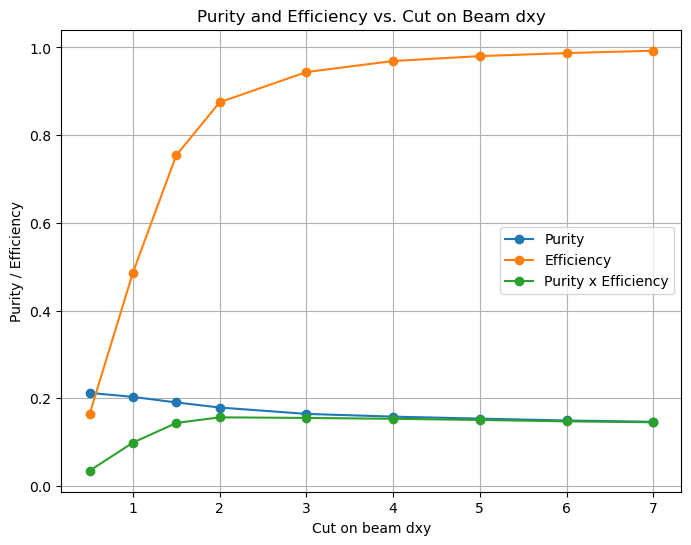

In [16]:
plt.figure(figsize=(8, 6))
plt.plot(rng, purity, marker="o", label="Purity")
plt.plot(rng, eff, marker="o", label="Efficiency")
plt.plot(rng, np.array(purity)*np.array(eff), marker="o", label="Purity x Efficiency")
plt.xlabel("Cut on beam dxy")
plt.ylabel("Purity / Efficiency")
plt.title("Purity and Efficiency vs. Cut on Beam dxy")
plt.legend()
plt.grid()
plt.show()

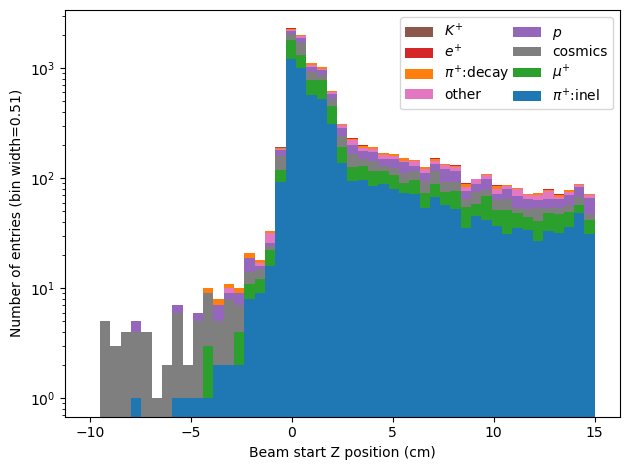

In [17]:
reco_startpos = track_evts.recoParticles.beam_startPos_SCE
tags = Tags.GenerateBeamCandidateTags(track_evts)
bins = np.linspace(-10, 15, 50)
Plots.PlotTagged(reco_startpos.z, tags, bins=bins, y_scale='log', x_label="Beam start Z position (cm)")

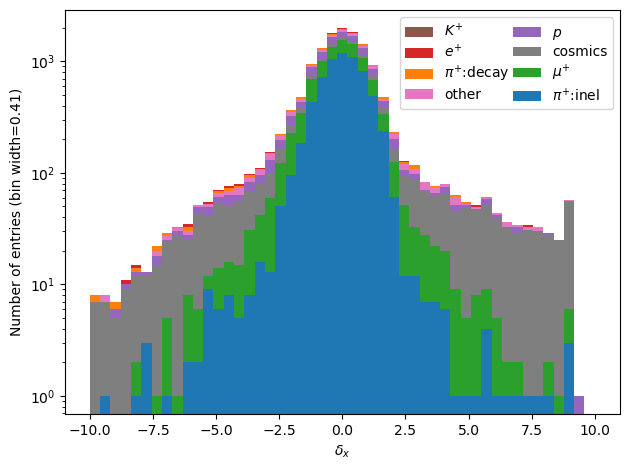

In [18]:
reco_startpos = track_evts.recoParticles.beam_startPos_SCE
beam_dx = (reco_startpos.x - mu["x"])/ sigma["x"]
tags = Tags.GenerateBeamCandidateTags(track_evts)
bins = np.linspace(-10, 10, 50)
Plots.PlotTagged(beam_dx, tags, bins=bins, y_scale='log', x_label="$\\delta_x$")
#plt.axvline(mu["x"], color="red", linestyle="--", label="Mean")

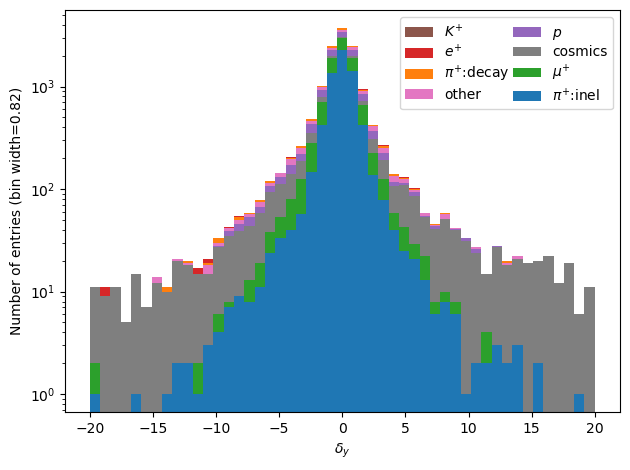

In [19]:
reco_startpos = track_evts.recoParticles.beam_startPos_SCE
beam_dy = (reco_startpos.y - mu["y"])/ sigma["y"]
tags = Tags.GenerateBeamCandidateTags(track_evts)
bins = np.linspace(-20, 20, 50)
Plots.PlotTagged(beam_dy, tags, bins=bins, y_scale='log', x_label="$\\delta_y$")
#plt.axvline(mu["y"], color="red", linestyle="--", label="Mean")

In [10]:
mask = beam_dxy < 3
track_selected_evts = track_evts.Filter([mask], [mask], returnCopy=True)

In [21]:
purity = ak.sum(beam_selection.signal_mask(track_selected_evts)) / len(beam_selection.signal_mask(track_selected_evts))
print(f"Purity after BV selection: {purity:.2%}")

eff_bt = ak.sum(beam_selection.signal_mask(track_selected_evts)) / ak.sum(beam_selection.signal_mask(track_evts))
eff_true = ak.sum(beam_selection.true_signal_mask(track_selected_evts)) / ak.sum(beam_selection.true_signal_mask(track_evts))
print(f"Efficiency of the BV selection from backtracking: {eff_bt:.2%}")
print(f"Efficiency of the BV selection from truth info: {eff_true:.2%}")

Purity after BV selection: 16.44%
Efficiency of the BV selection from backtracking: 94.39%
Efficiency of the BV selection from truth info: 77.69%


In [22]:
eff_bt = ak.sum(beam_selection.signal_mask(track_selected_evts)) / ak.sum(beam_selection.signal_mask(track_evts))
eff_true = ak.sum(beam_selection.true_signal_mask(track_selected_evts)) / ak.sum(beam_selection.true_signal_mask(track_evts))
print(f"Efficiency of the BV selection from backtracking: {eff_bt:.2%}")
print(f"Efficiency of the BV selection from truth info: {eff_true:.2%}")

Efficiency of the BV selection from backtracking: 94.39%
Efficiency of the BV selection from truth info: 77.69%


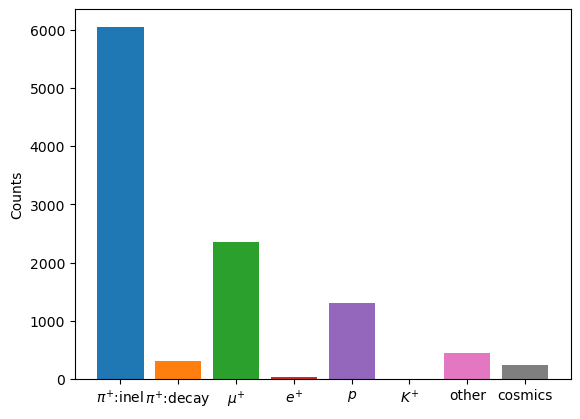

In [23]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
counts = ak.sum(tags.mask.values, axis=1)
#counts = counts/np.sum(counts)
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
plt.show()

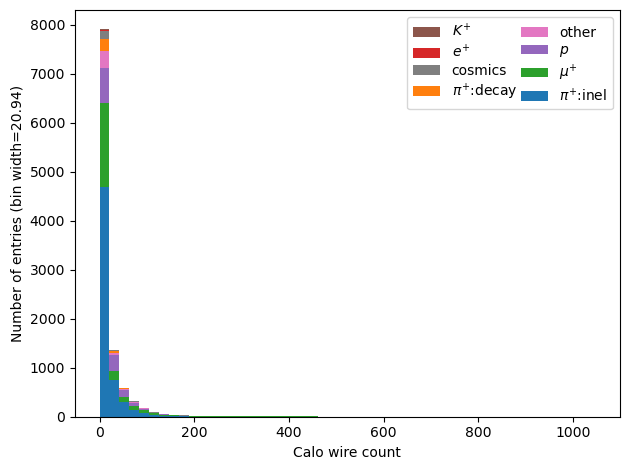

In [12]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
calo_wire = track_selected_evts.recoParticles.beam_caloWire_noSCE
Plots.PlotTagged(ak.num(calo_wire), tags, bins=50, y_scale='linear', x_label="Calo wire count")

In [13]:
ak.sum(ak.num(calo_wire)==0), ak.sum(ak.num(track_selected_evts.recoParticles.beam_dEdX_noSCE)==0)

(4796, 4796)

0


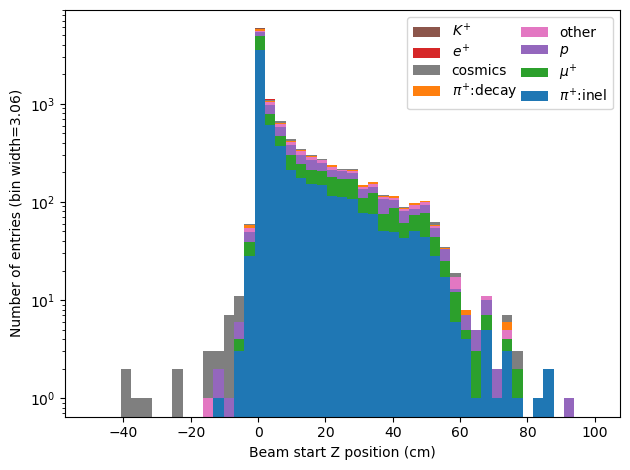

In [24]:
start_pos = track_selected_evts.recoParticles.beam_startPos_SCE
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
print(ak.sum(start_pos.z == -999))
bins=np.linspace(-50, 100, 50)
Plots.PlotTagged(start_pos.z, tags, bins=bins, y_scale='log', x_label="Beam start Z position (cm)")

0


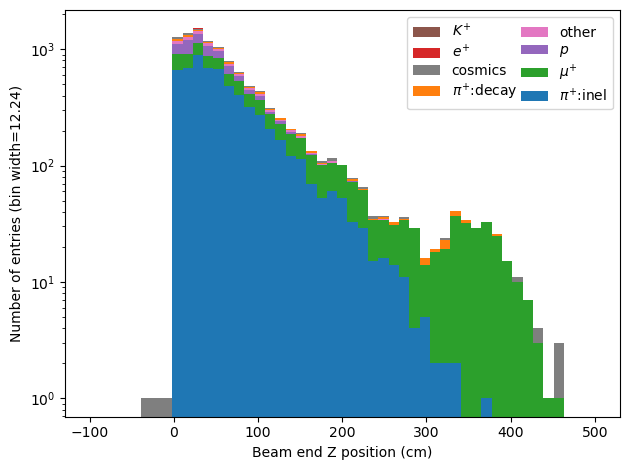

In [25]:
end_pos = track_selected_evts.recoParticles.beam_endPos_SCE
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
print(ak.sum(end_pos.z == -999))
Plots.PlotTagged(end_pos.z, tags, bins=np.linspace(-100, 500, 50), y_scale='log', x_label="Beam end Z position (cm)")

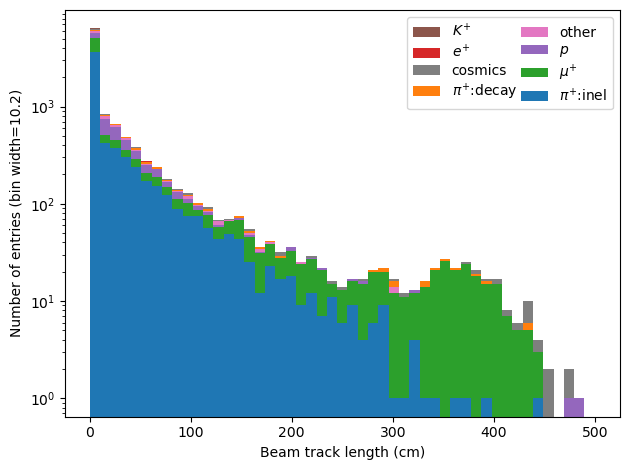

In [26]:
trk_len = track_selected_evts.recoParticles.beam_track_length
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(trk_len, tags, bins=np.linspace(0, 500, 50), y_scale='log', x_label="Beam track length (cm)")

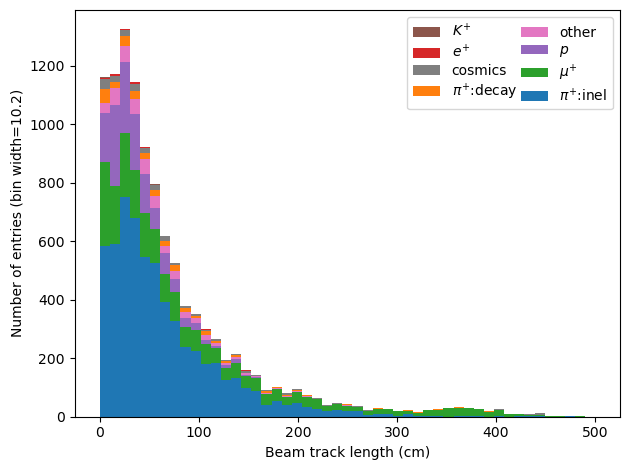

In [27]:
trk_len = track_selected_evts.recoParticles.reco_beam_len
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(trk_len, tags, bins=np.linspace(0, 500, 50), y_scale='linear', x_label="Beam track length (cm)")

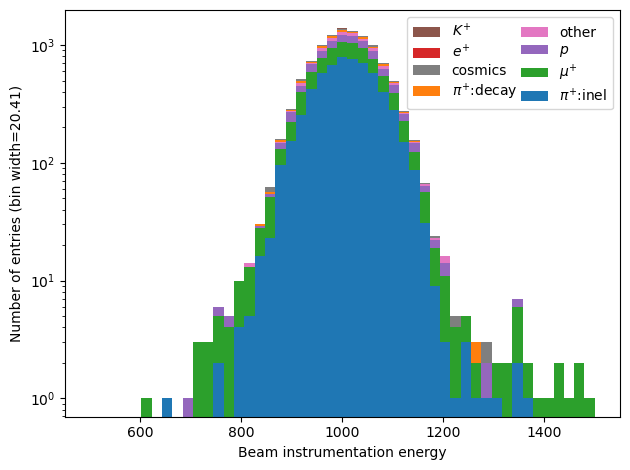

In [28]:
reco_inst_P = track_selected_evts.recoParticles.beam_inst_P
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(reco_inst_P, tags, bins=np.linspace(500, 1500, 50), y_scale='log', x_label="Beam instrumentation energy")

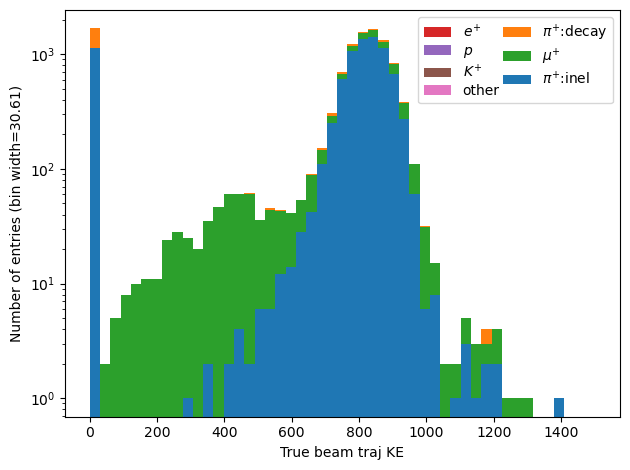

In [29]:
ff_mask = beam_selection.tpc_entrance_mask(track_selected_evts)
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
true_KE_ff = ak.fill_none(ak.firsts(track_selected_evts.trueParticles.beam_traj_KE[ff_mask]), 0)
bins = np.linspace(0, 1500, 50)
Plots.PlotTagged(true_KE_ff, tags, bins=bins, y_scale='log', x_label="True beam traj KE")

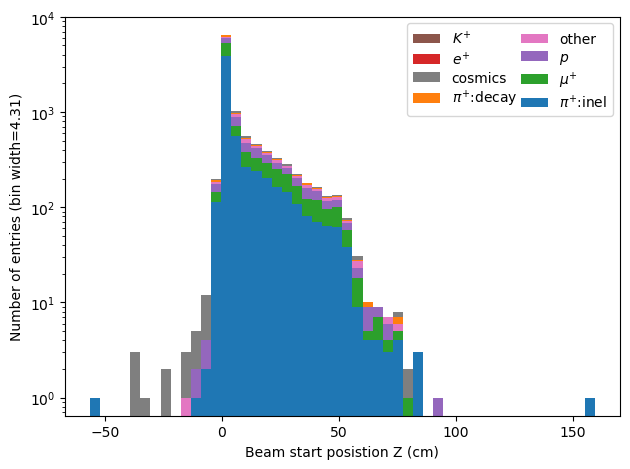

In [30]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(track_selected_evts.recoParticles.beam_startPos_SCE.z, tags, bins=50, y_scale='log', x_label="Beam start posistion Z (cm)")

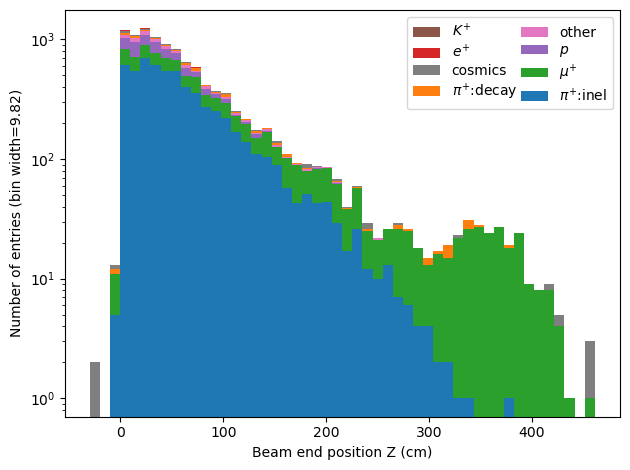

In [31]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(track_selected_evts.recoParticles.beam_endPos_SCE.z, tags, bins=50, y_scale='log', x_label="Beam end position Z (cm)")

In [32]:
dEdX = track_selected_evts.recoParticles.beam_dEdX
#bins = np.linspace(np.nanpercentile(sorted(ak.flatten(dEdX)), 1), np.nanpercentile(sorted(ak.flatten(dEdX)), 99), 50)
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(dEdX, tags, bins=bins, y_scale='log', x_label="Beam dE/dX")

KeyboardInterrupt: 

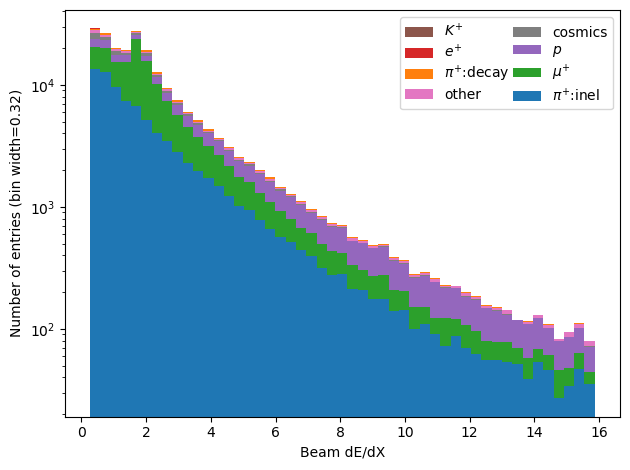

In [ ]:
dEdX = track_selected_evts.recoParticles.beam_dEdX
bins = np.linspace(np.nanpercentile(sorted(ak.flatten(dEdX)), 1), np.nanpercentile(sorted(ak.flatten(dEdX)), 99), 50)
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(dEdX, tags, bins=bins, y_scale='log', x_label="Beam dE/dX")

In [ ]:
true_track_len = track_selected_evts.trueParticles.beam_track_length
bins = np.linspace(0, 600, 50)
counts, _ = np.histogram(true_track_len, bins=bins)
print(counts, bins)

[2612  791  783  634  586  531  422  369  355  283  257  229  225  189
  184  171  140  148  113   96  100   72   64   81   67   61   67  124
  154  171  176  154  107  107   60   37   13    3    1    1    3    2
    1    1    1    1    0    1    0] [  0.          12.24489796  24.48979592  36.73469388  48.97959184
  61.2244898   73.46938776  85.71428571  97.95918367 110.20408163
 122.44897959 134.69387755 146.93877551 159.18367347 171.42857143
 183.67346939 195.91836735 208.16326531 220.40816327 232.65306122
 244.89795918 257.14285714 269.3877551  281.63265306 293.87755102
 306.12244898 318.36734694 330.6122449  342.85714286 355.10204082
 367.34693878 379.59183673 391.83673469 404.08163265 416.32653061
 428.57142857 440.81632653 453.06122449 465.30612245 477.55102041
 489.79591837 502.04081633 514.28571429 526.53061224 538.7755102
 551.02040816 563.26530612 575.51020408 587.75510204 600.        ]


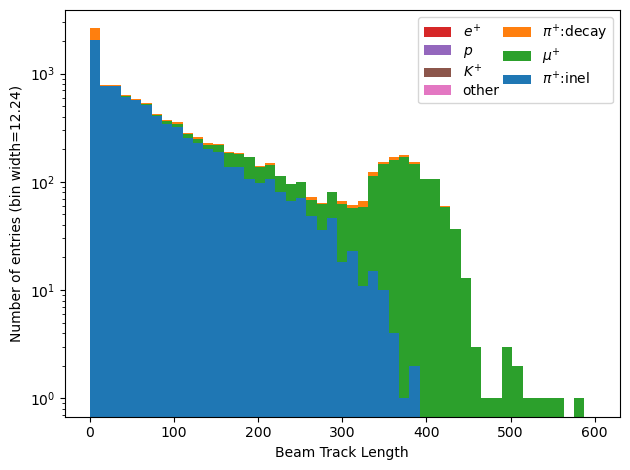

In [ ]:
true_track_len = track_selected_evts.trueParticles.beam_track_length
bins = np.linspace(0, 600, 50)
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
Plots.PlotTagged(true_track_len, tags, bins=bins, y_scale='log', x_label="Beam Track Length")

In [ ]:
# from python.analysis.PFOSelection import Median

# def MedianDEdXCut(events: Data, cut : float = 2.4, op = "<", truncate : float = None, return_property : bool = False) -> ak.Array:
#     """ cut on median dEdX to exlude proton background.

#     Args:
#         events (Data): events to study.

#     Returns:
#         ak.Array: boolean mask.
#     """
#     if truncate is None:
#         dEdX = events.recoParticles.beam_dEdX
#         print(f"dEdX: {dEdX}")
#     else:
#         dEdX = GetTruncatedDEdX(events, truncate)
#     print(f"dEdX: {dEdX}")
#     median = Median(dEdX)
#    return CreateMask(cut, op, median, return_property)

In [ ]:
from python.analysis.PFOSelection import Median

median = Median(track_selected_evts.recoParticles.beam_dEdX)

In [ ]:
track_selected_evts.event_index

<Array [0, 7, 9, ... 181283, 181297, 181331] type='10748 * int64'>

In [ ]:
ak.sum(median==-999)

4796

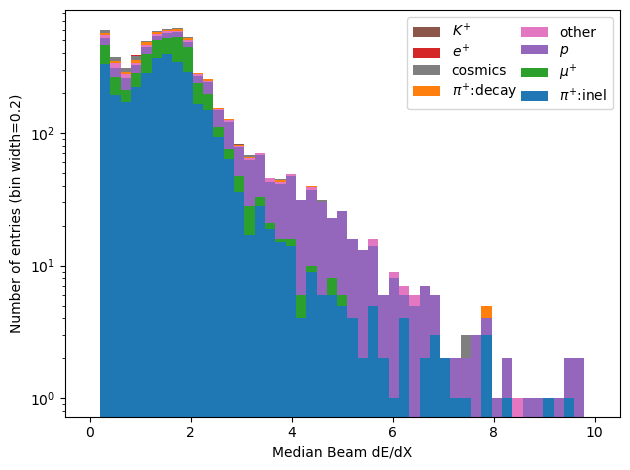

In [ ]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(median, tags, bins=np.linspace(0, 10, 50), y_scale="log", x_label="Median Beam dE/dX")

In [ ]:
def Mean(x : ak.Array):
    s = ak.sort(x, -1)
    count = ak.num(s, -1)

    # calculate the mean
    mean = ak.sum(s, -1) / count
    return mean

/software/gj23442/miniconda3/envs/pdune_analysis/lib/python3.10/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in divide
  result = getattr(ufunc, method)(


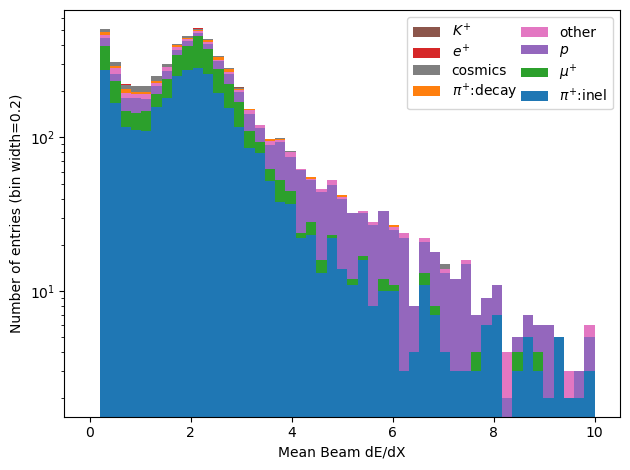

In [ ]:
mean = Mean(track_selected_evts.recoParticles.beam_dEdX)
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(mean, tags, bins=np.linspace(0, 10, 50), y_scale="log", x_label="Mean Beam dE/dX")

In [ ]:

def truncated_mean(jagged_dedx, keep_fraction=0.75):
    # Sort each event's hits ascending (vectorised over all events)
    sorted_dedx = ak.sort(jagged_dedx, axis=-1)
    
    # Per-event number of hits to keep
    n_hits = ak.num(sorted_dedx, axis=-1)
    n_keep = np.maximum(1, np.floor(n_hits * keep_fraction))
    
    # Pad to rectangular, then mask out hits beyond n_keep cutoff
    # ak.local_index gives [0,1,2,...] index array per event
    local_idx = ak.local_index(sorted_dedx, axis=-1)
    mask = local_idx < n_keep  # True for hits to keep, broadcast-safe
    
    kept = sorted_dedx[mask]   # still jagged, but top % removed
    
    return ak.mean(kept, axis=-1)  # vectorised mean per event

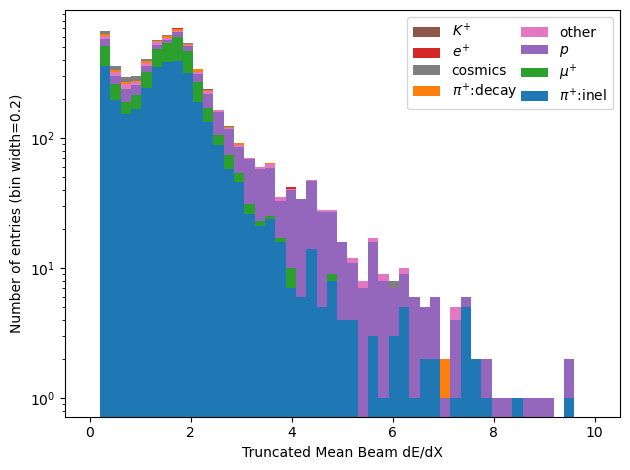

In [ ]:
trunc_mean = truncated_mean(track_selected_evts.recoParticles.beam_dEdX, keep_fraction=0.9)
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(trunc_mean, tags, bins=np.linspace(0, 10, 50), y_scale="log", x_label="Truncated Mean Beam dE/dX")

In [ ]:
ak.sum(track_selected_evts.recoParticles.beam_michelScore == -1)

9487

In [ ]:
len(track_selected_evts.recoParticles.beam_michelScore)

10748

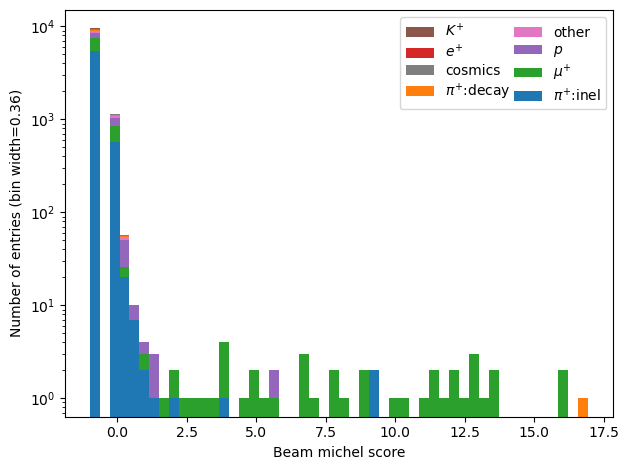

In [ ]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(track_selected_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

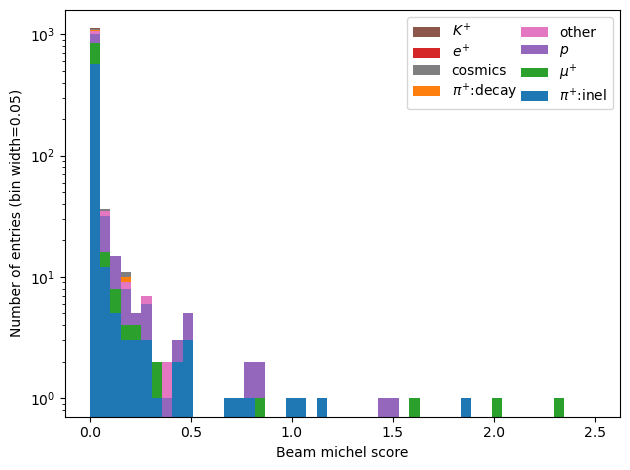

In [ ]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
bins = np.linspace(0, 2.5, 50)
Plots.PlotTagged(track_selected_evts.recoParticles.beam_michelScore, tags, bins=bins, y_scale='log', x_label="Beam michel score")

In [ ]:
ak.sum(track_selected_evts.recoParticles.beam_nHits == 0)

10124

In [ ]:
ak.sum(track_selected_evts.recoParticles.beam_michelScore == -1)

9487

In [ ]:
ak.sum(track_selected_evts.recoParticles.beam_track_length<=5)

5788

In [ ]:
ak.sum(np.minimum(track_selected_evts.recoParticles.beam_startPos_SCE.z, track_selected_evts.recoParticles.beam_endPos_SCE.z) < 25)

9444

In [ ]:
mask = (np.minimum(track_selected_evts.recoParticles.beam_startPos_SCE.z, track_selected_evts.recoParticles.beam_endPos_SCE.z) < 25) | (track_selected_evts.recoParticles.beam_track_length < 5) 

In [ ]:
ak.sum(mask)

10166

In [ ]:
mask = track_selected_evts.recoParticles.beam_michelScore == -1 
filtered_evts = track_selected_evts.Filter([mask], [mask], returnCopy=True)
filtered_evts.event_index

<Array [0, 7, 9, ... 181283, 181297, 181331] type='9487 * int64'>

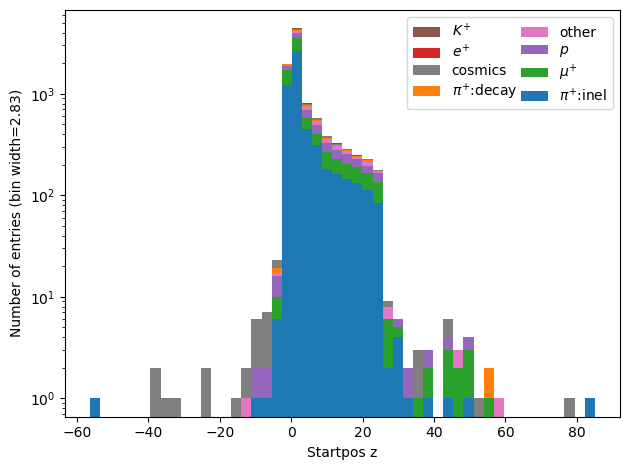

In [ ]:
tags = Tags.GenerateBeamCandidateTags(filtered_evts)
Plots.PlotTagged(filtered_evts.recoParticles.beam_startPos_SCE.z, tags, bins=50, y_scale='log', x_label="Startpos z")

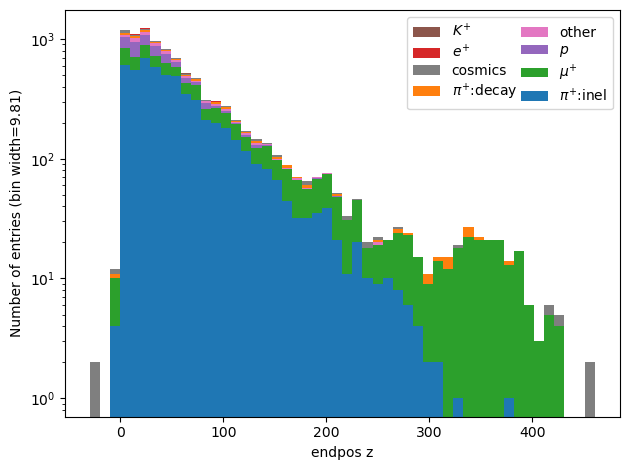

In [ ]:
tags = Tags.GenerateBeamCandidateTags(filtered_evts)
Plots.PlotTagged(filtered_evts.recoParticles.beam_endPos_SCE.z, tags, bins=50, y_scale='log', x_label="endpos z")

In [ ]:
max(track_selected_evts.recoParticles.beam_michelScore)

16.954571772384497

In [ ]:
len(track_selected_evts.recoParticles.beam_nHits)

10748

In [ ]:
ak.sum(track_selected_evts.recoParticles.beam_michelScore == -1)

9487

In [ ]:
ak.sum(track_selected_evts.recoParticles.beam_nHits == 0)

10124

In [ ]:
ak.sum(track_selected_evts.recoParticles.beam_michelScore_by_charge == -999)

10124

4796


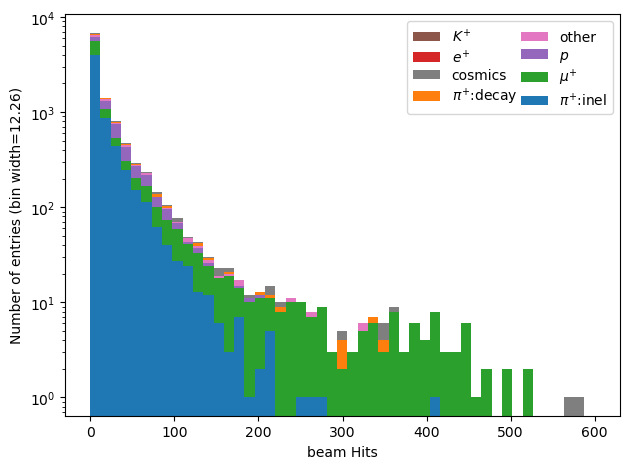

In [ ]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
print(ak.sum(ak.num(track_selected_evts.recoParticles.beam_dEdX) == 0))
Plots.PlotTagged(ak.num(track_selected_evts.recoParticles.beam_dEdX), tags, bins=np.linspace(-0.5, 600, 50), y_scale='log', x_label="beam Hits")

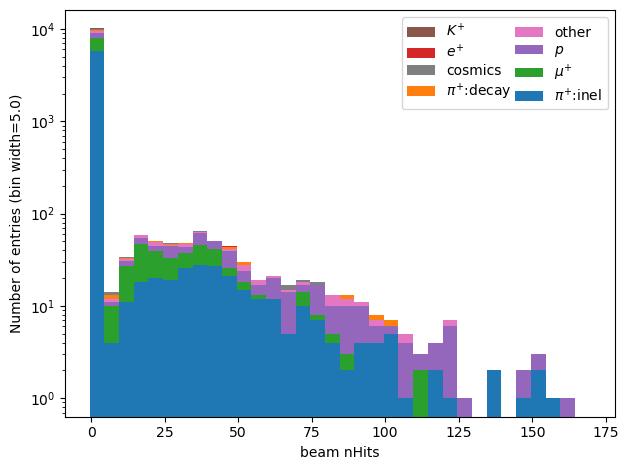

In [ ]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(track_selected_evts.recoParticles.beam_nHits, tags, bins=np.arange(-0.5, 170, 5), y_scale='log', x_label="beam nHits")

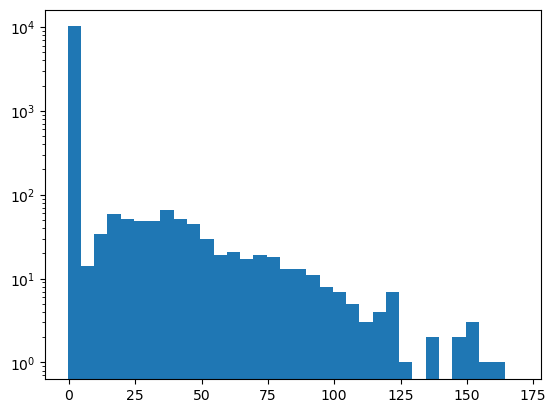

In [ ]:
plt.hist(track_selected_evts.recoParticles.beam_nHits, bins=np.arange(-0.5, 170, 5))
plt.yscale("log")
plt.show()

In [ ]:
from python.analysis import vector

end_pos = track_selected_evts.recoParticles.beam_endPos_SCE
start_pos = track_selected_evts.recoParticles.beam_startPos_SCE
beam_dir = vector.normalize(vector.sub(end_pos, start_pos))

In [ ]:
mu_dir = {i : ak.mean(ak.nan_to_num(beam_dir[i])) for i in ["x", "y", "z"]}
mu_dir_err = {i : ak.std(ak.nan_to_num(beam_dir[i]))/np.sqrt(ak.count(beam_dir[i])) for i in ["x", "y", "z"]}

mu_dir

{'x': -0.16493111682469902, 'y': -0.19484187752109935, 'z': 0.7891122503508978}

In [ ]:
beam_dir_mc = vector.normalize(vector.vector(mu_dir["x"], mu_dir["y"], mu_dir["z"]))
beam_dir_mc

<Array [{x: -0.199, y: -0.235, z: 0.951}] type='1 * {"x": float64, "y": float64,...'>

In [ ]:
beam_costh = vector.dot(beam_dir, beam_dir_mc)

In [ ]:
from python.analysis import vector

end_pos = track_selected_evts.recoParticles.beam_endPos_SCE
start_pos = track_selected_evts.recoParticles.beam_startPos_SCE
beam_dir = vector.normalize(vector.sub(end_pos, start_pos))

mu_dir = {i : ak.mean(ak.nan_to_num(beam_dir[i])) for i in ["x", "y", "z"]}
mu_dir_err = {i : ak.std(ak.nan_to_num(beam_dir[i]))/np.sqrt(ak.count(beam_dir[i])) for i in ["x", "y", "z"]}

beam_dir_mc = vector.normalize(vector.vector(mu_dir["x"], mu_dir["y"], mu_dir["z"]))
beam_costh = vector.dot(beam_dir, beam_dir_mc)

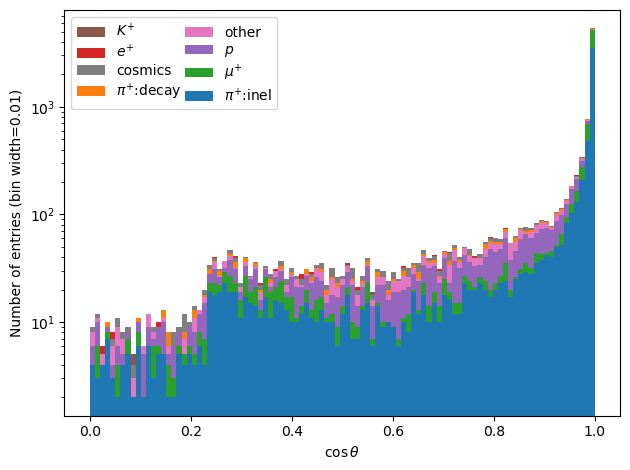

In [ ]:
bins = np.linspace(0, 1, 100)
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(beam_costh, tags, bins=bins, y_scale='log', x_label=r'$\cos\theta$ ')
#plt.xlim(0.9, 1)

In [ ]:
from python.analysis import vector

end_pos = track_evts.recoParticles.beam_endPos_SCE
start_pos = track_evts.recoParticles.beam_startPos_SCE
beam_dir = vector.normalize(vector.sub(end_pos, start_pos))

mu_dir = {i : ak.mean(ak.nan_to_num(beam_dir[i])) for i in ["x", "y", "z"]}
mu_dir_err = {i : ak.std(ak.nan_to_num(beam_dir[i]))/np.sqrt(ak.count(beam_dir[i])) for i in ["x", "y", "z"]}

beam_dir_mc = vector.normalize(vector.vector(mu_dir["x"], mu_dir["y"], mu_dir["z"]))
beam_costh = vector.dot(beam_dir, beam_dir_mc)

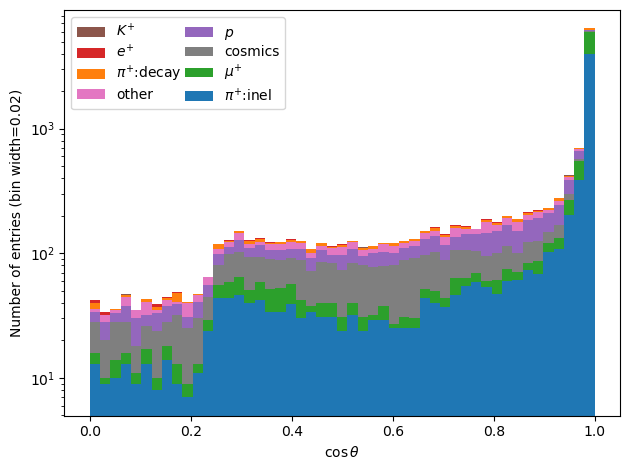

In [ ]:
bins = np.linspace(0.0, 1, 50)
tags = Tags.GenerateBeamCandidateTags(track_evts)
Plots.PlotTagged(beam_costh, tags, bins=bins, y_scale='log', x_label=r'$\cos\theta$ ')
#plt.xlim(0.9, 1)